<a href="https://colab.research.google.com/github/youyoy92700/nlp/blob/main/Copie_de_lab3_Part2_WordEmbeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install gensim transformers torch sentence-transformers datasets

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [ ]:
import pandas as pd

# Load the dataset
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}

df = pd.read_json(
    "hf://datasets/SetFit/20_newsgroups/" + splits["train"],
    lines=True
)

# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["comp.graphics", "rec.sport.hockey", "sci.space"]  # COPY FROM PART 1

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Selected categories: ['comp.graphics', 'rec.sport.hockey', 'sci.space']
Filtered dataset size: 1777


In [ ]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove emails
    text = re.sub(r'\S+@\S+', '', text)

    # 4. Remove mentions and hashtags
    text = re.sub(r'[@#]\w+', '', text)

    # 5. Remove punctuation (keep letters/numbers)
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # 6. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 7. Tokenization
    tokens = text.split()

    # 8. Remove stopwords + lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['weiteks', 'addressphone', 'number', 'like', 'get', 'information', 'chip']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [ ]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1777 documents
Total tokens: 181472

Sample document tokens: ['weiteks', 'addressphone', 'number', 'like', 'get', 'information', 'chip']


In [ ]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 5546


In [ ]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 5546


### A.2 Exploring Word Embeddings

In [ ]:
# Example: Get word vector
sample_word = "computer"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'computer':
  Shape: (100,)
  First 10 values: [ 0.452127    0.83741015  0.1223757   0.01392354  0.75416094 -0.2144643
 -0.02910262  0.47364292  0.10651178 -0.7152477 ]


In [ ]:
# Find similar words
sample_word = "computer"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'computer' (CBOW):
  user: 0.9885
  application: 0.9878
  visualization: 0.9772
  tool: 0.9724
  virtual: 0.9715
  environment: 0.9698
  unix: 0.9693
  database: 0.9688
  map: 0.9683
  software: 0.9664

Words most similar to 'computer' (Skip-gram):
  exponent: 0.7945
  graeme: 0.7574
  graphic: 0.7475
  film: 0.7428
  raytracing: 0.7395
  programmer: 0.7268
  iris: 0.7227
  berlin: 0.7185
  gem: 0.7175
  personal: 0.7164


### Exercise A.2: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [ ]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["image", "game", "space", "team", "program"]  # YOUR WORDS HERE

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'image':
  CBOW:     ['display', 'format', 'screen', '24bit', 'color']
  Skip-gram: ['gif', 'lossless', 'menu', 'enhancement', 'fullcolor']

'game':
  CBOW:     ['played', 'playoff', 'pick', 'season', 'cup']
  Skip-gram: ['playoff', 'played', 'afternoon', 'regularseason', 'seven']

'space':
  CBOW:     ['station', 'nasa', 'shuttle', 'national', 'technology']
  Skip-gram: ['federal', 'civilian', 'nasajscgm2', 'jsc', '4834368']

'team':
  CBOW:     ['nhl', 'playoff', 'league', 'season', 'played']
  Skip-gram: ['nhl', 'salary', 'assat', 'helsinki', 'cap']

'program':
  CBOW:     ['support', 'run', 'software', 'hardware', 'library']
  Skip-gram: ['shareware', 'hijaak', 'pictpixie', 'insure', 'utility']


### Written Question A.2 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. Similar results for: game, team (same sports context)

2. Different results for: image, space, program (CBOW = general, Skip-gram = more specific)

3. Better model for my domain:
   - Example 1: image → CBOW: general (color), Skip-gram: specific (gif, lossless)
   - Example 2: space → CBOW: general (nasa), Skip-gram: technical (jsc)

4. Explanation of differences: Skip-gram works better for rare/technical words, while CBOW is better for frequent words and captures more general context.

### A.3 Word Analogies

In [ ]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.3: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [ ]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
# YOUR CODE HERE
analogy1 = find_analogy(model_skipgram, "gif", "image", "video")
print(f"Analogy 1: {analogy1}")

# Analogy 2
# YOUR CODE HERE
analogy2 = find_analogy(model_skipgram, "nasa", "space", "ship")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('signal', 0.7357435822486877), ('input', 0.6874514818191528), ('interface', 0.6769976019859314), ('analysis', 0.676728367805481), ('quantitative', 0.6667358875274658)]
Analogy 2: [('srb', 0.6696459054946899), ('oxygen', 0.6665711998939514), ('isp', 0.6639919877052307), ('casing', 0.6598504185676575), ('tilt', 0.6592264771461487)]


### Written Question A.3 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

*[Analyze your analogy results]*

For Analogy 1, the results like analysis, signal, digital are somewhat related to the technical domain, but they do not clearly match the intended relationship (image → video format). This suggests the model captured a general semantic field (technology/data processing) rather than a precise analogy.

For Analogy 2, the results (heat, oxide, casing) are not relevant . This indicates that the model failed to capture the analogy structure.

---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [ ]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
GloVe loaded! Vocabulary size: 400000


In [ ]:
# Compare: Same word in YOUR model vs GloVe
test_word = "computer"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'computer':

Your Word2Vec model:
  exponent: 0.7945
  graeme: 0.7574
  graphic: 0.7475
  film: 0.7428
  raytracing: 0.7395
  programmer: 0.7268
  iris: 0.7227
  berlin: 0.7185
  gem: 0.7175
  personal: 0.7164

Pre-trained GloVe:
  computers: 0.8752
  software: 0.8373
  technology: 0.7642
  pc: 0.7366
  hardware: 0.7290
  internet: 0.7287
  desktop: 0.7234
  electronic: 0.7222
  systems: 0.7198
  computing: 0.7142


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [ ]:
# TODO: Compare 3 domain-specific words

comparison_words = ["nasa", "game", "image"]  # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'nasa'
Your Word2Vec:
  ames: 0.819
  dryden: 0.792
  langley: 0.762
  shafer: 0.760
  jsc: 0.745
GloVe:
  shuttle: 0.778
  astronauts: 0.764
  spacecraft: 0.709
  space: 0.704
  endeavour: 0.692

Word: 'game'
Your Word2Vec:
  playoff: 0.758
  played: 0.732
  afternoon: 0.729
  regularseason: 0.722
  seven: 0.716
GloVe:
  games: 0.864
  play: 0.832
  season: 0.773
  player: 0.758
  players: 0.729

Word: 'image'
Your Word2Vec:
  gif: 0.748
  lossless: 0.713
  menu: 0.703
  enhancement: 0.702
  fullcolor: 0.700
GloVe:
  images: 0.734
  picture: 0.728
  symbol: 0.673
  color: 0.662
  seen: 0.660


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. My model is better for: ...
   - Reason: ...

2. GloVe is better for: ...
   - Reason: ...

3. When to use each:
   - Custom model: ...
   - Pre-trained model: ...

### B.2 GloVe Analogies

In [ ]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [ ]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: nasa is to space as nhl is to ?
result1 = glove_model.most_similar(
    positive=['nhl', 'space'],
    negative=['nasa'],
    topn=3
)
print("Analogy 1:")
print(result1)

# Analogy 2: shuttle is to space as game is to ?
result2 = glove_model.most_similar(
    positive=['game', 'space'],
    negative=['shuttle'],
    topn=3
)
print("\nAnalogy 2:")
print(result2)

# Analogy 3: image is to graphics as program is to ?
result3 = glove_model.most_similar(
    positive=['program', 'graphics'],
    negative=['image'],
    topn=3
)
print("\nAnalogy 3:")
print(result3)

Analogy 1:
[('franchise', 0.7148790955543518), ('hockey', 0.6971903443336487), ('league', 0.6805480718612671)]

Analogy 2:
[('games', 0.7394102215766907), ('play', 0.6966811418533325), ('player', 0.6491848230361938)]

Analogy 3:
[('programs', 0.6629108786582947), ('programming', 0.5692158937454224), ('programmes', 0.5336742997169495)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [ ]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


In [ ]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [ ]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [ ]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [ ]:
# TODO: Encode documents with BERT and compute similarity matrix

#  créer le modèle
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Vérifier les données
sample_docs = df_filtered['text_clean'].tolist()[:100]

# Step 1: Encode all sampled documents
doc_embeddings = bert_model.encode(sample_docs, convert_to_tensor=True)

# Step 2: Compute cosine similarity
bert_similarity = util.cos_sim(doc_embeddings, doc_embeddings)

print(f"Similarity matrix shape: {bert_similarity.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Similarity matrix shape: torch.Size([100, 100])


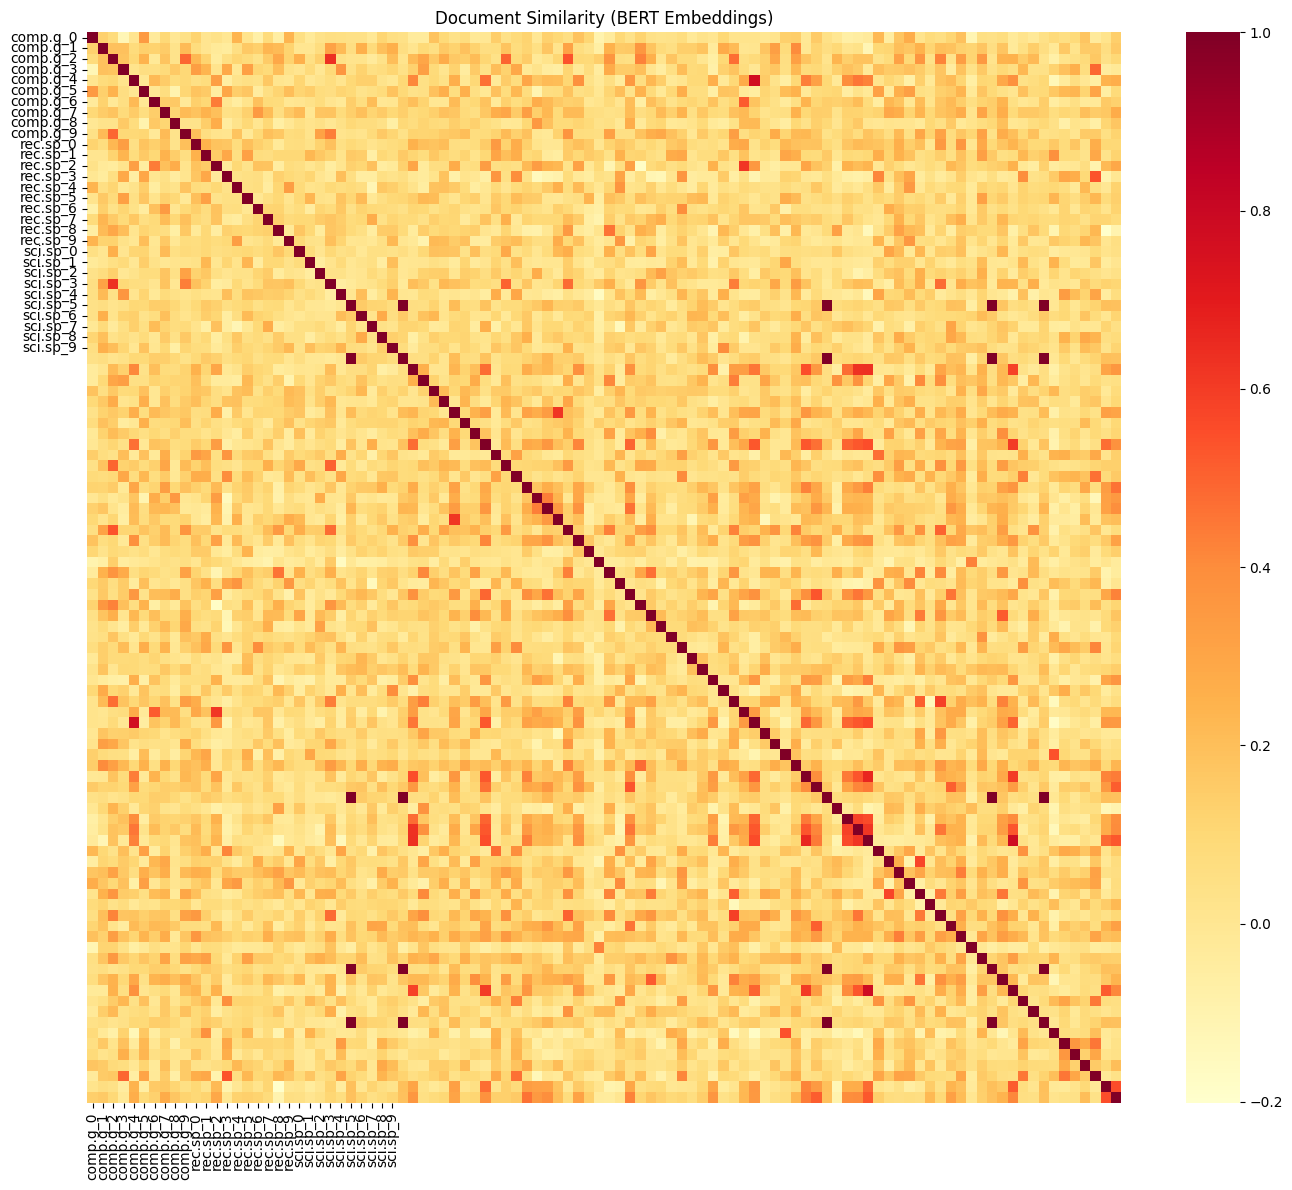

In [ ]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. Better clustering with: ...

2. Differences between methods: ...

3. Preferred method for classification: ...

### Exercise C.2: Semantic Search with BERT

In [ ]:
# TODO: Create a simple semantic search function
# Given a query, find the most similar documents

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.

    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return

    Returns:
        list: List of (index, similarity_score) tuples
    """
 # 1. Encode the query
    query_embedding = model.encode(query, convert_to_tensor=True)

    # 2. Encode all documents
    doc_embeddings = model.encode(documents, convert_to_tensor=True)

    # 3. Compute similarity with all documents
    similarities = util.cos_sim(query_embedding, doc_embeddings)[0]

    # 4. Get top_k most similar documents
    top_results = similarities.topk(k=top_k)

    # 5. Return (index, score)
    results = [(idx.item(), score.item()) for score, idx in zip(top_results.values, top_results.indices)]


    return []

# Test your search function
# TODO: Write a query related to ONE of your categories
my_query = "space shuttle nasa orbit mission"


results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'space shuttle nasa orbit mission'

Top 5 most similar documents:


### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. Relevance: ...

2. Category accuracy: ...

3. Ambiguous query test: ...

---

## Part D: Embedding Visualization with t-SNE

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce BERT embeddings to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings.cpu())

# Plot
plt.figure(figsize=(12, 8))

colors = {'comp.graphics': 'red','rec.sport.hockey': 'blue','sci.space': 'green'}

for category in my_categories:
    mask = [l == category for l in sampled_labels]

    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        color=colors[category],
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

IndexError: boolean index did not match indexed array along axis 0; size of axis is 100 but size of corresponding boolean axis is 30

<Figure size 1200x800 with 0 Axes>

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. Cluster quality: ...

2. Misplaced documents: ...

3. Most similar categories: ...

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

### 2. Best Method for My Dataset

*[Write at least 4-5 sentences with specific evidence]*

...

### 3. My Recommendation for a Real System

*[Write your recommendation and justification]*

...

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found